# Titanic - Machine Learning from Disaster

**Objective**: Predict passenger survival on the Titanic using machine learning through cleaning, and feature analysis, and model training

**Data Source**: [Kaggle: Titanic - Machine Learning from Disaster](https://www.kaggle.com/c/titanic)

**Inspired and modified in accordance with**: [Titanic - Advanced Feature Engineering Tutorial](https://www.kaggle.com/code/gunesevitan/titanic-advanced-feature-engineering-tutorial#3.-Model)

## Packages installation and libraries importation

In [188]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost mlflow shap mlflow xgboost lightgbm catboost mlxtend

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [189]:
# Some common libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

## Exploratory Data Analysis

### Data overview

In [190]:
df_train = pd.read_csv('../data/raw/train.csv')
print(f"Initial dataset shape: {df_train.shape}")
print(df_train.shape)
print(df_train.info())
df_train.head()

Initial dataset shape: (891, 12)
(891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [191]:
df_test = pd.read_csv('../data/raw/test.csv')
print(f"Test dataset shape: {df_test.shape}")
print(df_test.shape)
print(df_test.info())
df_test.head()

Test dataset shape: (418, 11)
(418, 11)
<class 'pandas.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Pclass       418 non-null    int64  
 2   Name         418 non-null    str    
 3   Sex          418 non-null    str    
 4   Age          332 non-null    float64
 5   SibSp        418 non-null    int64  
 6   Parch        418 non-null    int64  
 7   Ticket       418 non-null    str    
 8   Fare         417 non-null    float64
 9   Cabin        91 non-null     str    
 10  Embarked     418 non-null    str    
dtypes: float64(2), int64(4), str(5)
memory usage: 36.1 KB
None


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [192]:
df_train = df_train.drop(['PassengerId'], axis=1)

- Survived:
    + 1: Survived
    + 0: Not survived

- Pclass: A proxy for socio-economic status (SES)
    + 1st = Upper
    + 2nd = Middle
    + 3rd = Lower

- Age: Age is fractional if less than 1, it in the form of x.5 if estimated

- Sibsp:
    + Sibling = brother, sister, stepbrother, stepsister
    + Spouse = husband, wife (mistresses and fiances were ignored)

- Parch:
    + Parent = mother, father
    + Child = daughter, son, stepdaughter, stepson
    + Some children travelled only with a nanny, therefore parch=0 for them.

- Ticket: Families or groupes had purchased tickets together shared the same ticket number. However, they tickets can be different if there were multiple transactions.

- Fare: The price of ticket, can be associated with family size

- Cabin: Range from A-G with 80% missing values

- Embarked: Where the passengers boarded the ship: Cherbourg, Queenstown, Southampton

### Plot functions

In [193]:
def group_by_col_and_plot(df, col):
    gr = df.groupby(col, observed=False).size().to_frame(name='Count')
    gr['Ratio'] = np.round(gr['Count'] / gr['Count'].sum() * 100, 0)
    
    print(f'Total number of {col}: {gr["Count"].sum()}')
    
    colors = sns.color_palette(n_colors=len(gr))
    
    # Create subplots
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Bar chart
    gr['Count'].plot(kind='bar', ax=ax1, color=colors, title=f'{col} Counts')
    ax1.set_xlabel('')
    ax1.set_ylabel('Count')
    ax1.tick_params(axis='x', rotation=0)
    
    # Pie chart
    gr['Ratio'].plot(kind='pie', ax=ax2, colors=colors, title=f'{col} Ratio', autopct='%1.1f%%', ylabel='')   

    plt.tight_layout()
    plt.show()
    

In [194]:
def distribution_plot(df, col):
    surv = df['Survived'] == 1

    _, ax = plt.subplots(1, 1, figsize=(12, 12))

    # Distribution of survival in feature
    sns.histplot(data=df, x=df[~surv][col], label='Not Survived', kde=True, color='#e74c3c')   
    sns.histplot(data=df, x=df[surv][col] , label='Survived', kde=True, color='#2ecc71')
        
    ax.set_xlabel('')
        
    ax.tick_params(axis='x', labelsize=20)
    ax.tick_params(axis='y', labelsize=20)
        
    ax.legend(loc='upper right', prop={'size': 20})
    ax.set_title('Distribution of Survival in {}'.format(col), size=20, y=1.05)
            
    plt.show()

In [195]:
from scipy import stats
def is_significant(gr, threshold=0.05):
    # Chi-Square Test
    chi2, p, _, _ = stats.chi2_contingency(gr)
    
    # Cramer's V Calculation
    n = gr.sum().sum()
    min_dim = min(gr.shape[0], gr.shape[1]) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    
    # Interpretation
    if cramers_v <= 0.2:
        strength = "weak"
    elif cramers_v <= 0.6:
        strength = "moderate"
    else:
        strength = "strong"

    if p < threshold:
        print(f"Result: statistically significant (p = {p:.5e})")
        print(f"Correlation (Cramér's V): {cramers_v:.3f} ({strength} association)")
    else:
        print(f"Result: statistically insignificant (p = {p:.5e})")
        print(f"Correlation (Cramér's V): {cramers_v:.3f} ({strength} association)")
    

def group_by_2_cols(df, col_1, col_2):
    gr = df.groupby([col_1, col_2], observed=False).size().unstack(col_1, fill_value=0)
    print(gr)
    
    return gr

def plot_2_cols_chart(gr, col_1, col_2):
    gr_total = gr.sum(axis=1)
    gr = np.round(gr.divide(gr_total, axis=0) * 100, 2)
    gr_total_percentage = np.round((gr_total/gr_total.sum())*100, 2)
    
    colors = sns.color_palette(n_colors=sum(gr.nunique()))
    
    # Create subplots
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    # Bar chart
    gr.plot(kind='bar', ax=ax1, color=colors, title=f'Proportion of {col_1} per {col_2}')
    
    for container in ax1.containers:
        ax1.bar_label(container, fmt='%.2f')
    
    ax1.set_xlabel('')
    ax1.set_ylabel('%', rotation=1)
    ax1.tick_params(axis='x', rotation=0)
    
    # Pie chart
    gr_total_percentage.plot(kind='pie', ax=ax2, colors=colors, title=f'{col_1} Ratio', autopct='%1.1f%%', ylabel='')  

    plt.tight_layout()
    plt.show()
    
    return

### Sex

Total number of Sex: 891


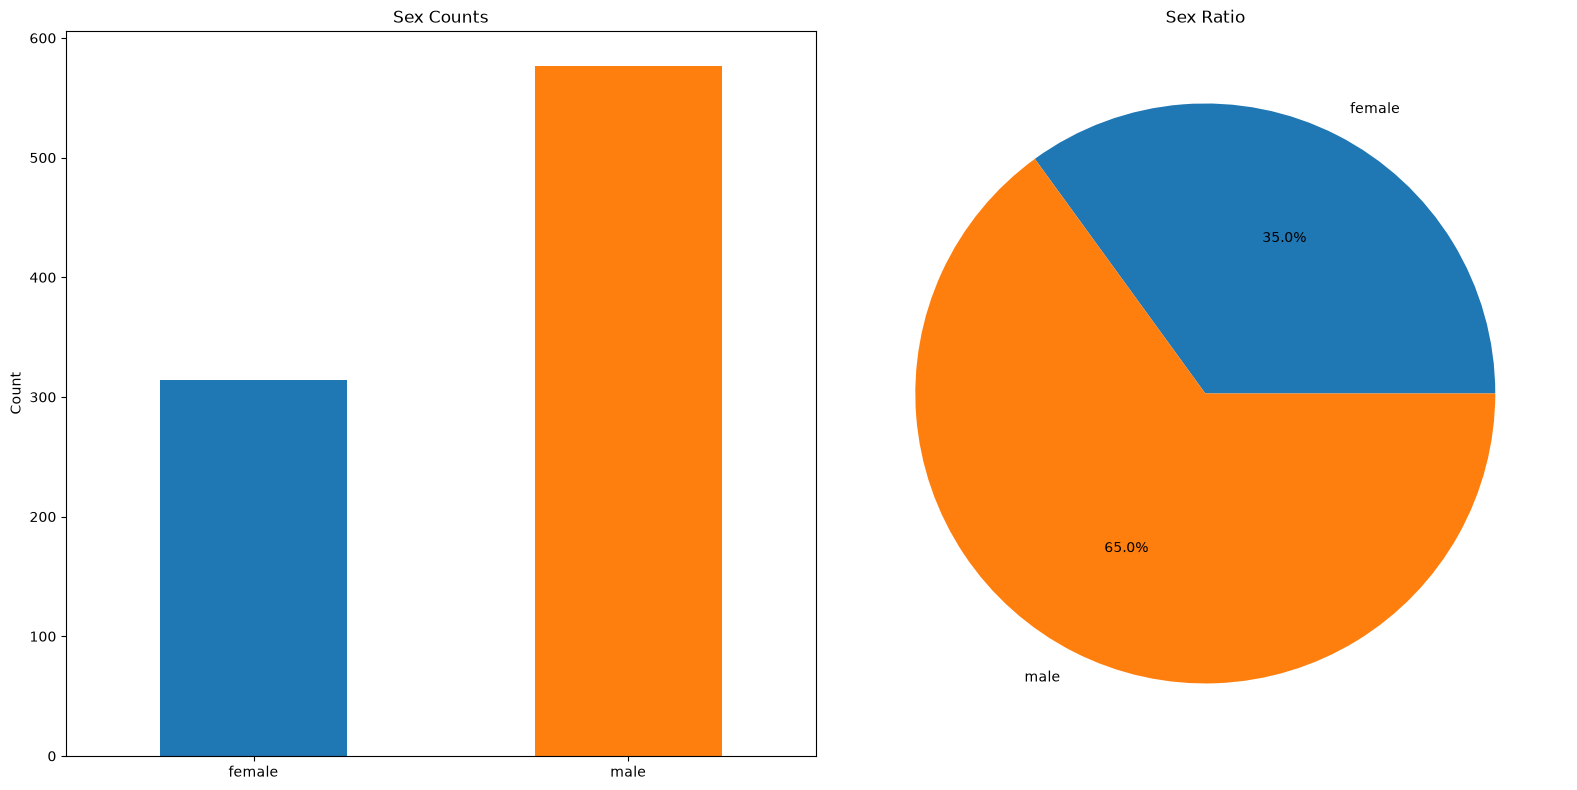

In [196]:
group_by_col_and_plot(df_train, col='Sex')

Survived    0    1
Sex               
female     81  233
male      468  109


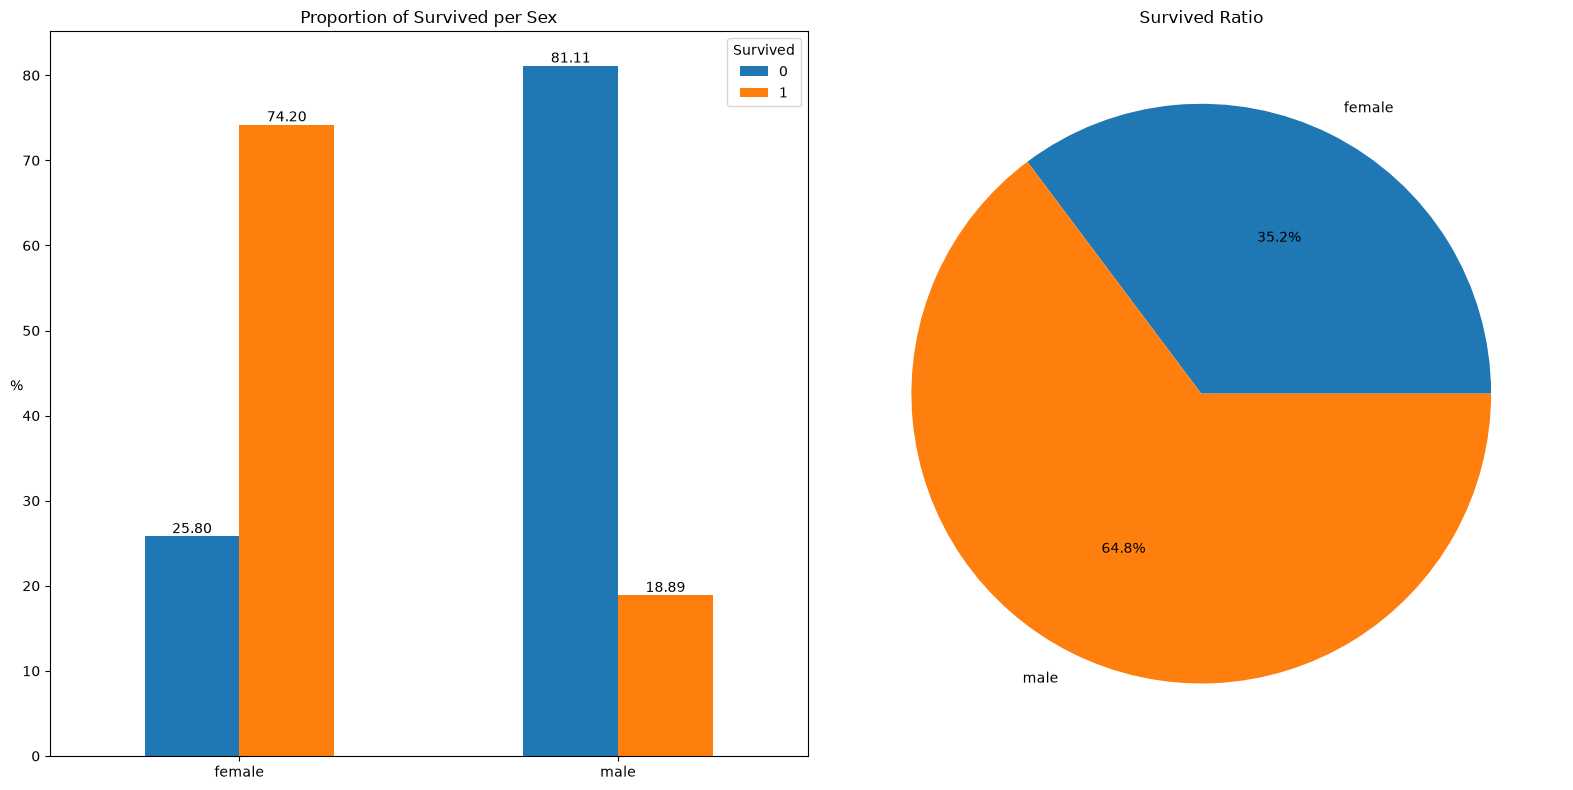

Result: statistically significant (p = 1.19736e-58)
Correlation (Cramér's V): 0.541 (moderate association)


In [197]:
gr = group_by_2_cols(df_train, col_1='Survived', col_2='Sex')
plot_2_cols_chart(gr, col_1='Survived', col_2='Sex')
is_significant(gr)

Gender was the dominant predictor of survival with females had a 74.2% survival rate while males had only an 18.9% survival rate.

### Age

In [198]:
age_by_pclass_sex = df_train.groupby(['Sex', 'Pclass'])['Age'].median()

for pclass in range(1, 4):
    for sex in ['female', 'male']:
        print('Median age of Pclass {} {}s: {}'.format(pclass, sex, age_by_pclass_sex[sex][pclass]))
print('Median age of all passengers: {}'.format(df_train['Age'].median()))

Median age of Pclass 1 females: 35.0
Median age of Pclass 1 males: 40.0
Median age of Pclass 2 females: 28.0
Median age of Pclass 2 males: 30.0
Median age of Pclass 3 females: 21.5
Median age of Pclass 3 males: 25.0
Median age of all passengers: 28.0


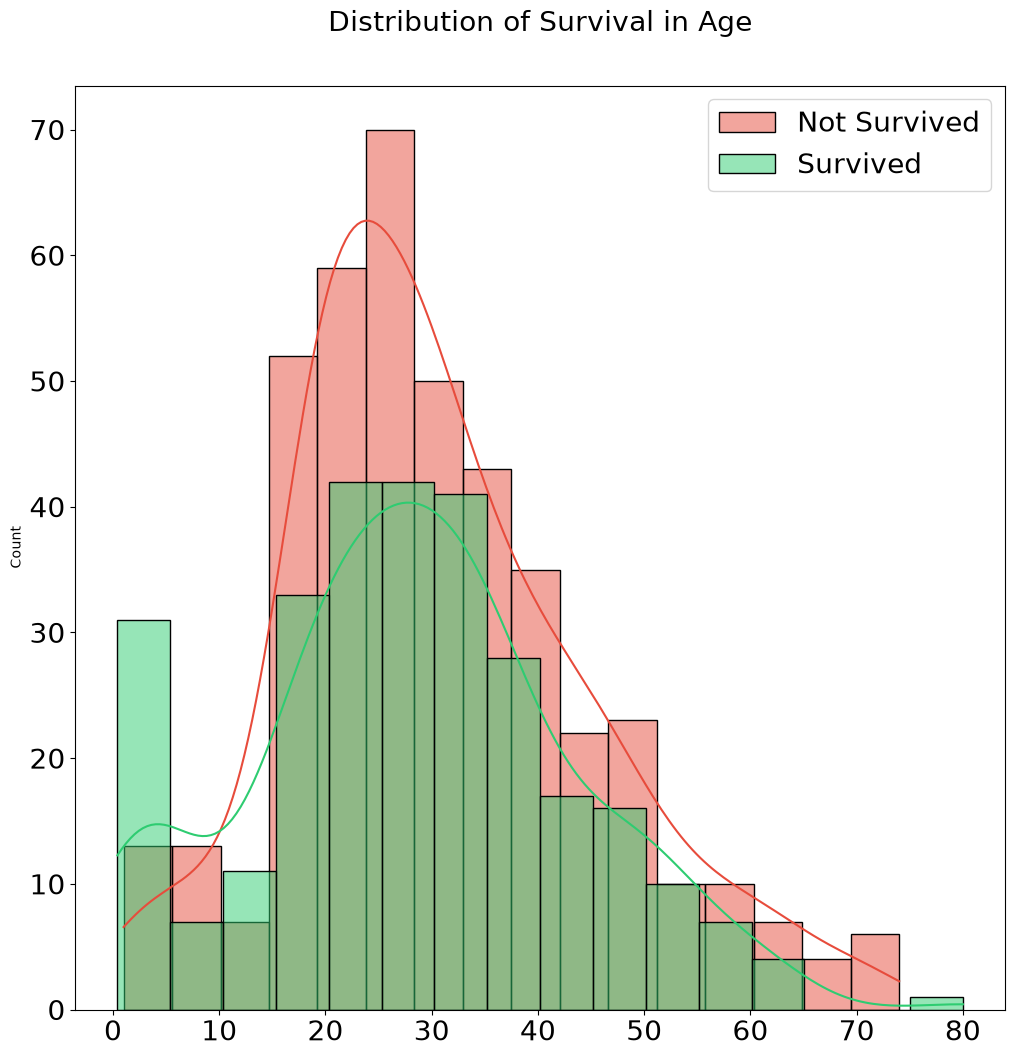

In [199]:
distribution_plot(df=df_train, col='Age')

The green "Survived" distribution shows a significant peak in the 0–10 age range, whereas the red "Not Survived" distribution is much lower in this bracket. The "Not Survived" group (red) has a much sharper and higher peak (reaching ~70 individuals) centered around ages 20–30. This indicates that the largest demographic of victims was young adults. Children seems to be a decisive factor for survivability.

### Fare

In [200]:
fare_by_pclass_sex = df_train.groupby(['Sex', 'Pclass'])['Fare'].median()

for pclass in range(1, 4):
    for sex in ['female', 'male']:
        print('Median fare of Pclass {} {}s: {}'.format(pclass, sex, fare_by_pclass_sex[sex][pclass]))
print('Median fare of all passengers: {}'.format(df_train['Fare'].median()))

Median fare of Pclass 1 females: 82.66454999999999
Median fare of Pclass 1 males: 41.2625
Median fare of Pclass 2 females: 22.0
Median fare of Pclass 2 males: 13.0
Median fare of Pclass 3 females: 12.475
Median fare of Pclass 3 males: 7.925
Median fare of all passengers: 14.4542


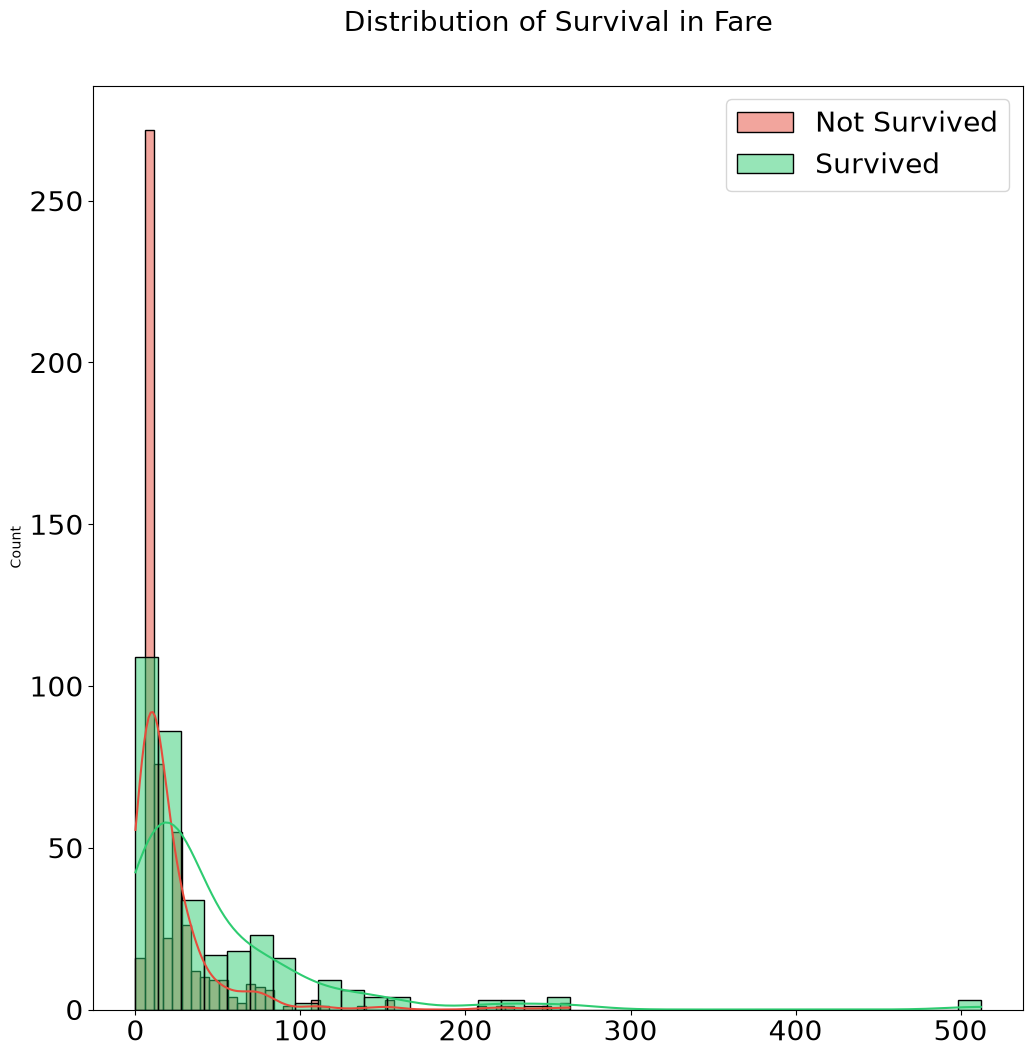

In [201]:
distribution_plot(df=df_train, col='Fare')

While the red "Not Survived" curve dominates the low-fare section, the green "Survived" curve is much more prominent in the higher fare ranges. This indicates that the vast majority of victims were passengers with the cheapest tickets (likely 3rd Class), who faced the greatest barriers to reaching the boat deck. The "Survived" distribution is flatter and extends further to the right. While many survivors also paid low fares, the proportion of survivors increases steadily as the fare price increases.

### Embarked

Total number of Embarked: 889


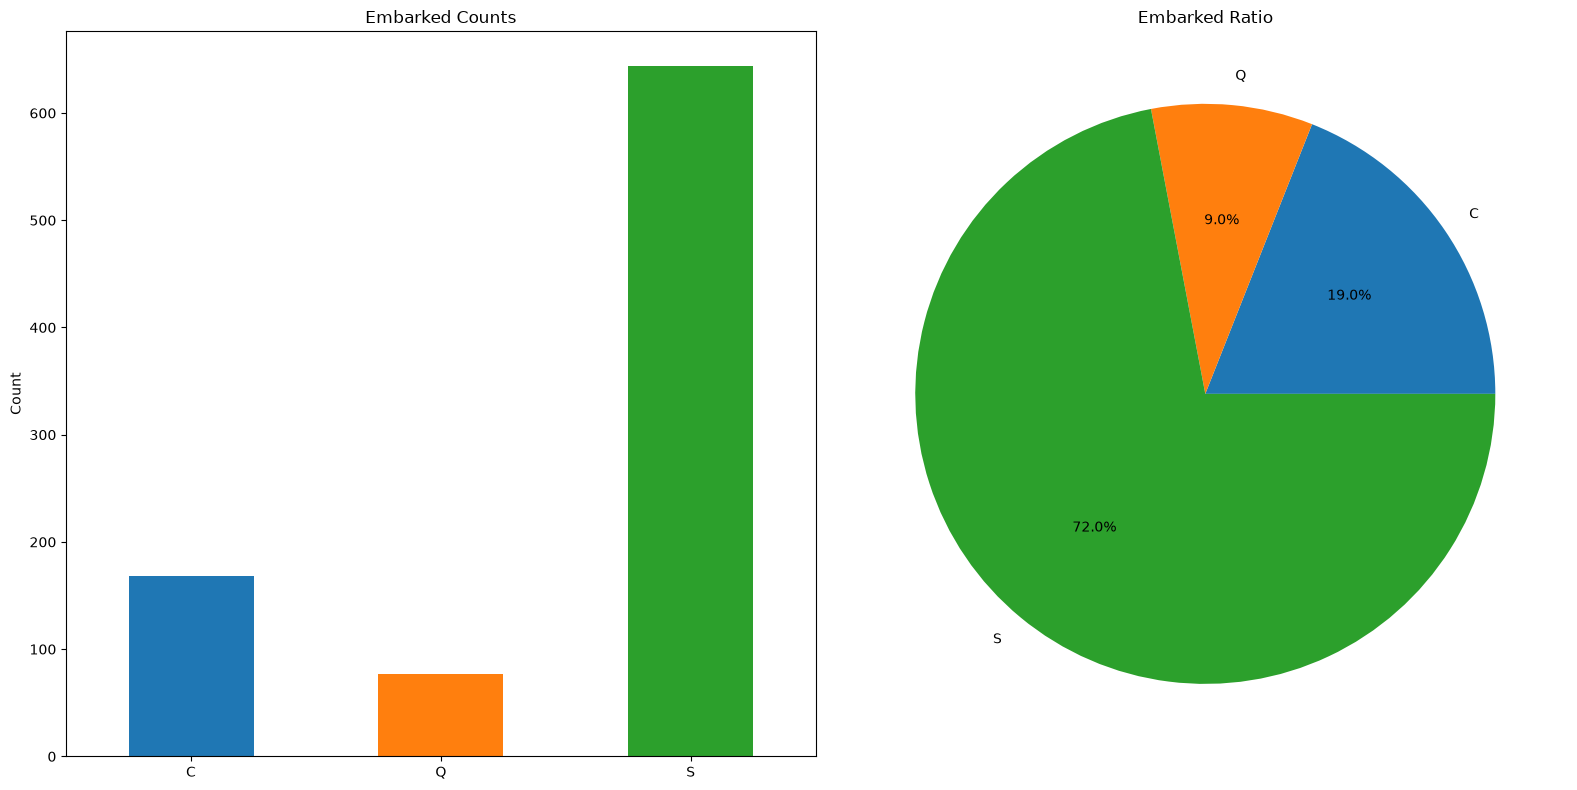

In [202]:
group_by_col_and_plot(df_train, col='Embarked')

Pclass      1    2    3
Embarked               
C          85   17   66
Q           2    3   72
S         127  164  353


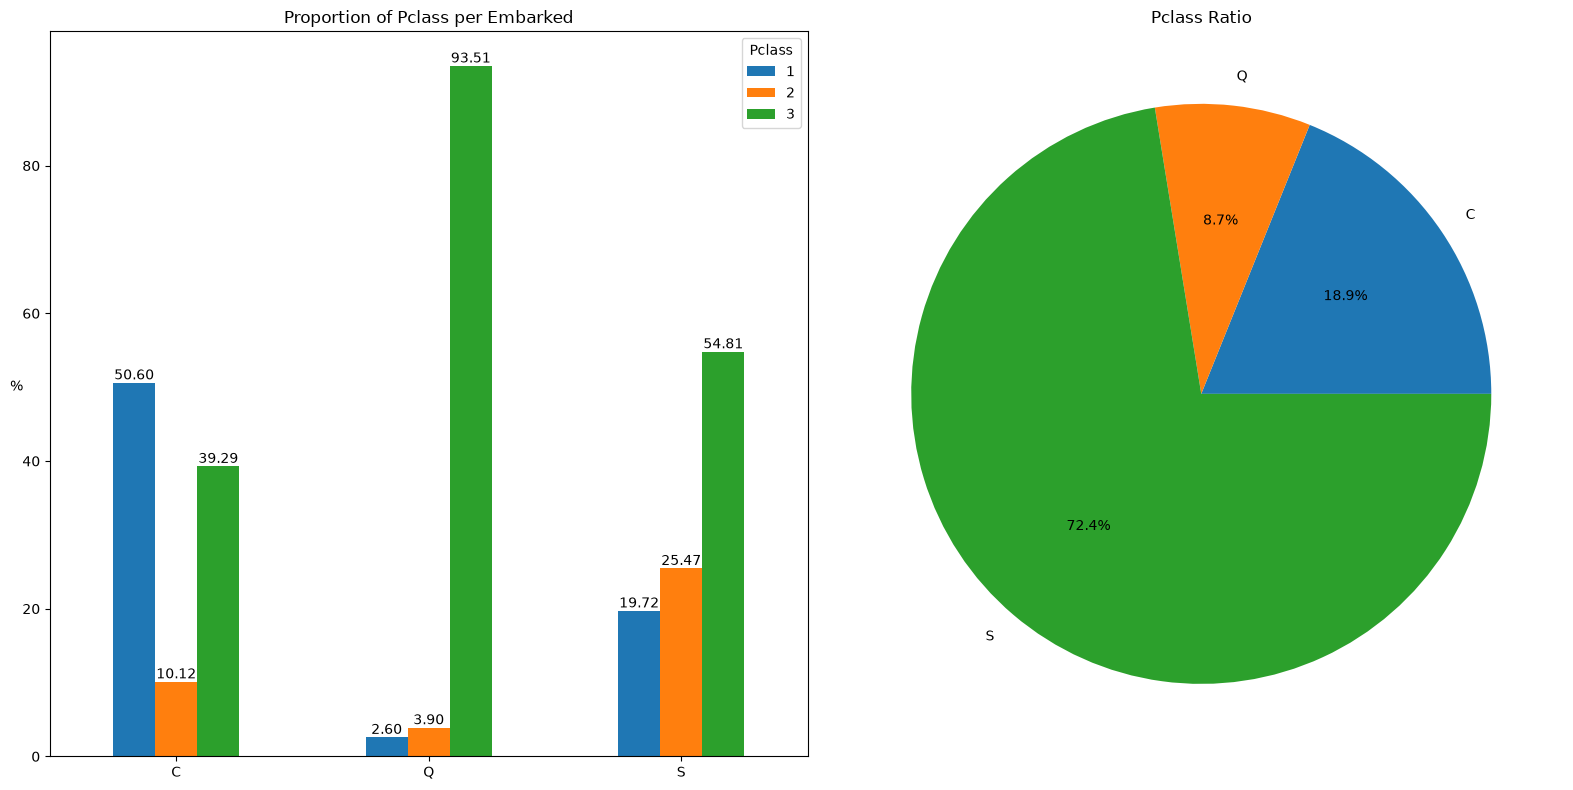

Result: statistically significant (p = 8.43527e-26)
Correlation (Cramér's V): 0.264 (moderate association)


In [203]:
gr = group_by_2_cols(df_train, col_1='Pclass', col_2='Embarked')
plot_2_cols_chart(gr, col_1='Pclass', col_2='Embarked')
is_significant(gr)

Queenstown seemed to be primarily a boarding point for 3r class passengers with 93.51%, while Cherbourg had over 50% of passengers from the upper classes. 

Survived    0    1
Embarked          
C          75   93
Q          47   30
S         427  217


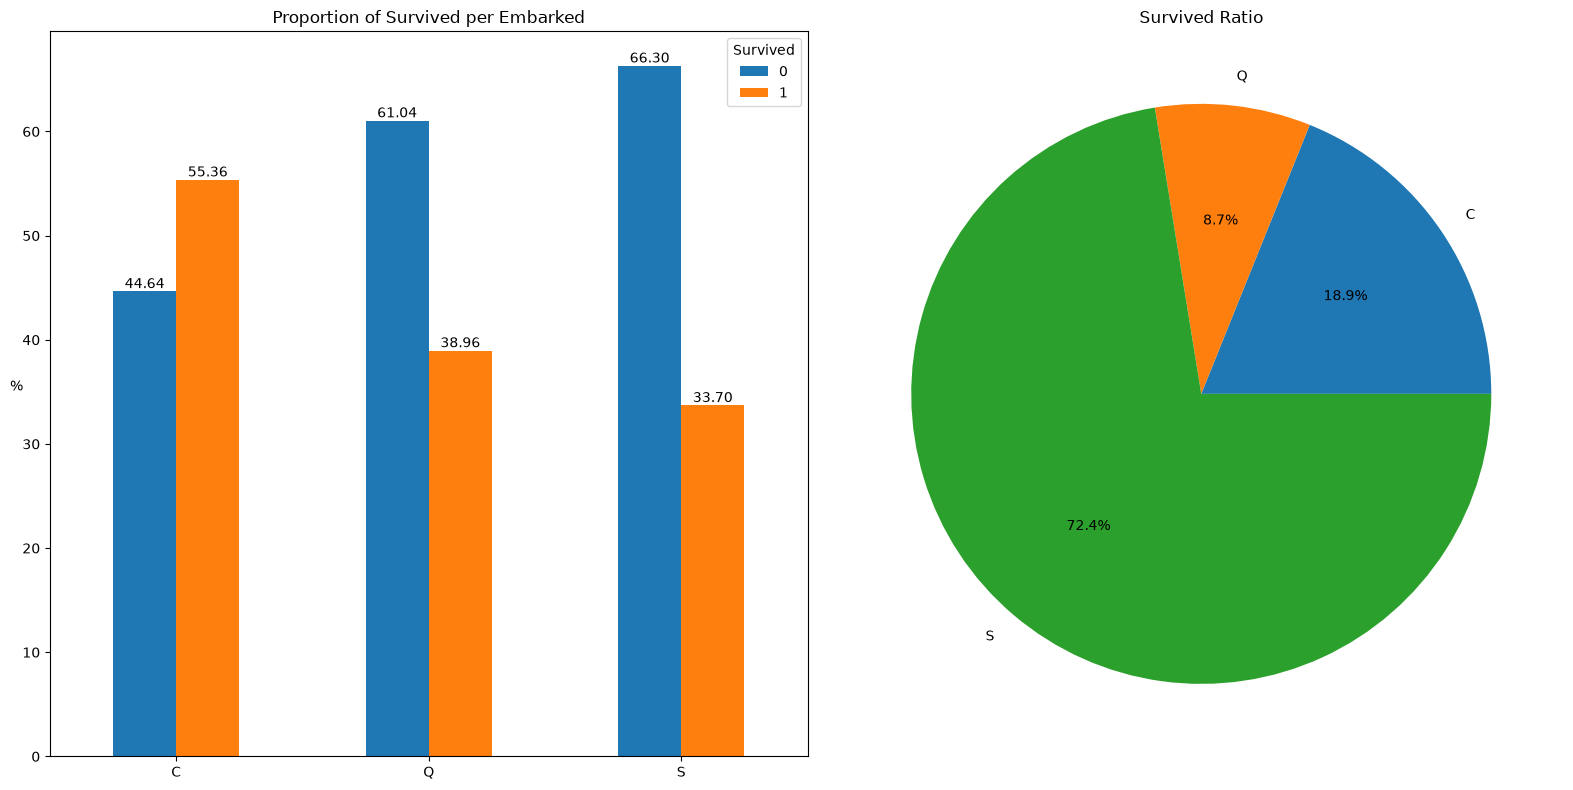

Result: statistically significant (p = 1.76992e-06)
Correlation (Cramér's V): 0.173 (weak association)


In [204]:
gr = group_by_2_cols(df_train, col_1='Survived', col_2='Embarked')
plot_2_cols_chart(gr, col_1='Survived', col_2='Embarked')
is_significant(gr)

There is a strong correlation between embarkation port and survival. Passengers boarding at Cherbourg were significantly more likely to survive than those from Queenstown or Southampton. This disparity is largely driven by socioeconomic class, as Cherbourg was a key entry point for 1st class passengers, while Queenstown served primarily 3rd class travellers.

### Pclass

Total number of Pclass: 891


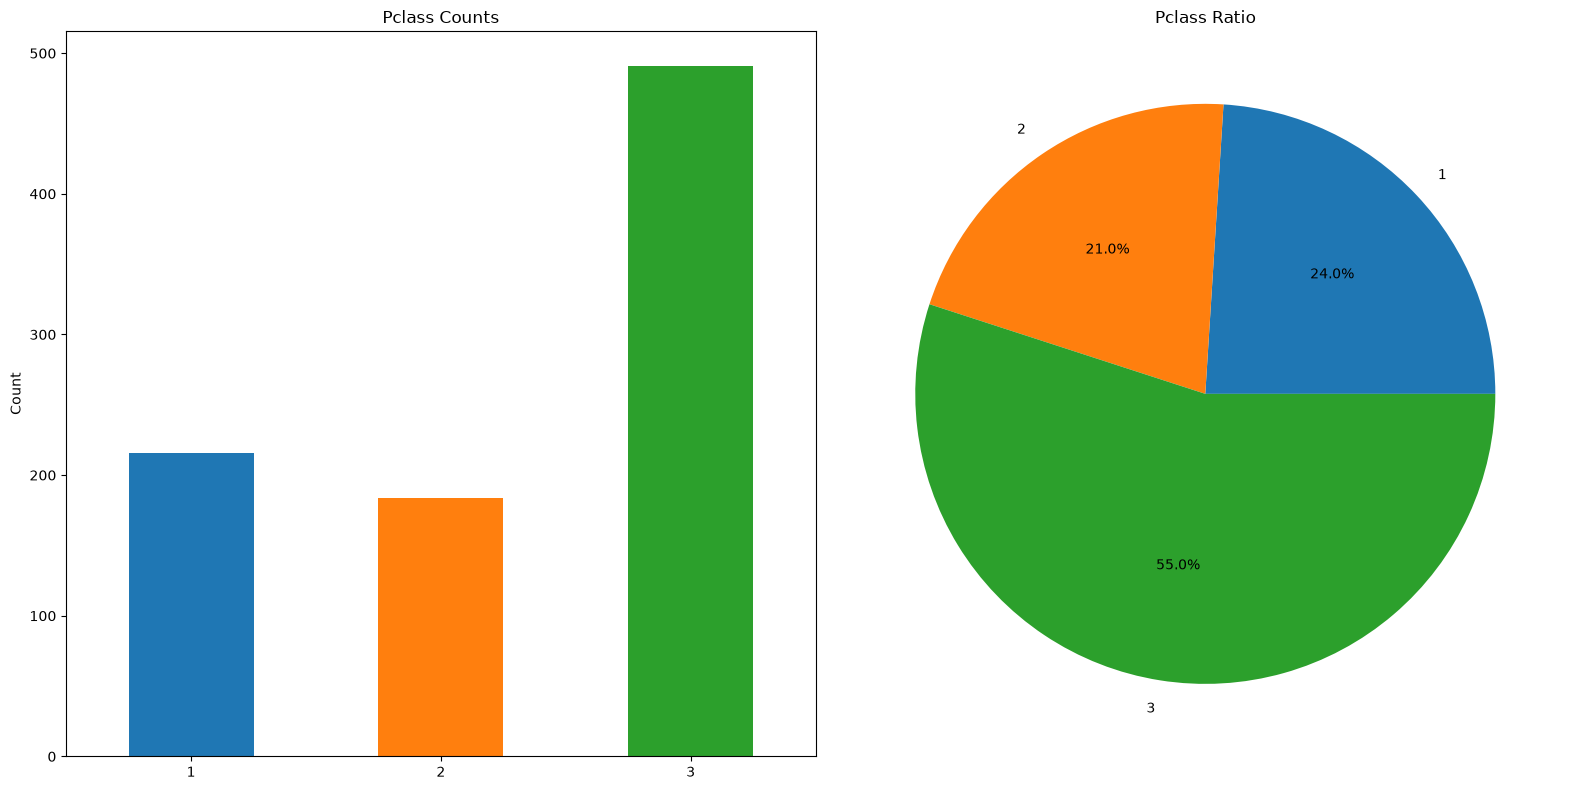

In [205]:
group_by_col_and_plot(df_train, col='Pclass')

Survived    0    1
Pclass            
1          80  136
2          97   87
3         372  119


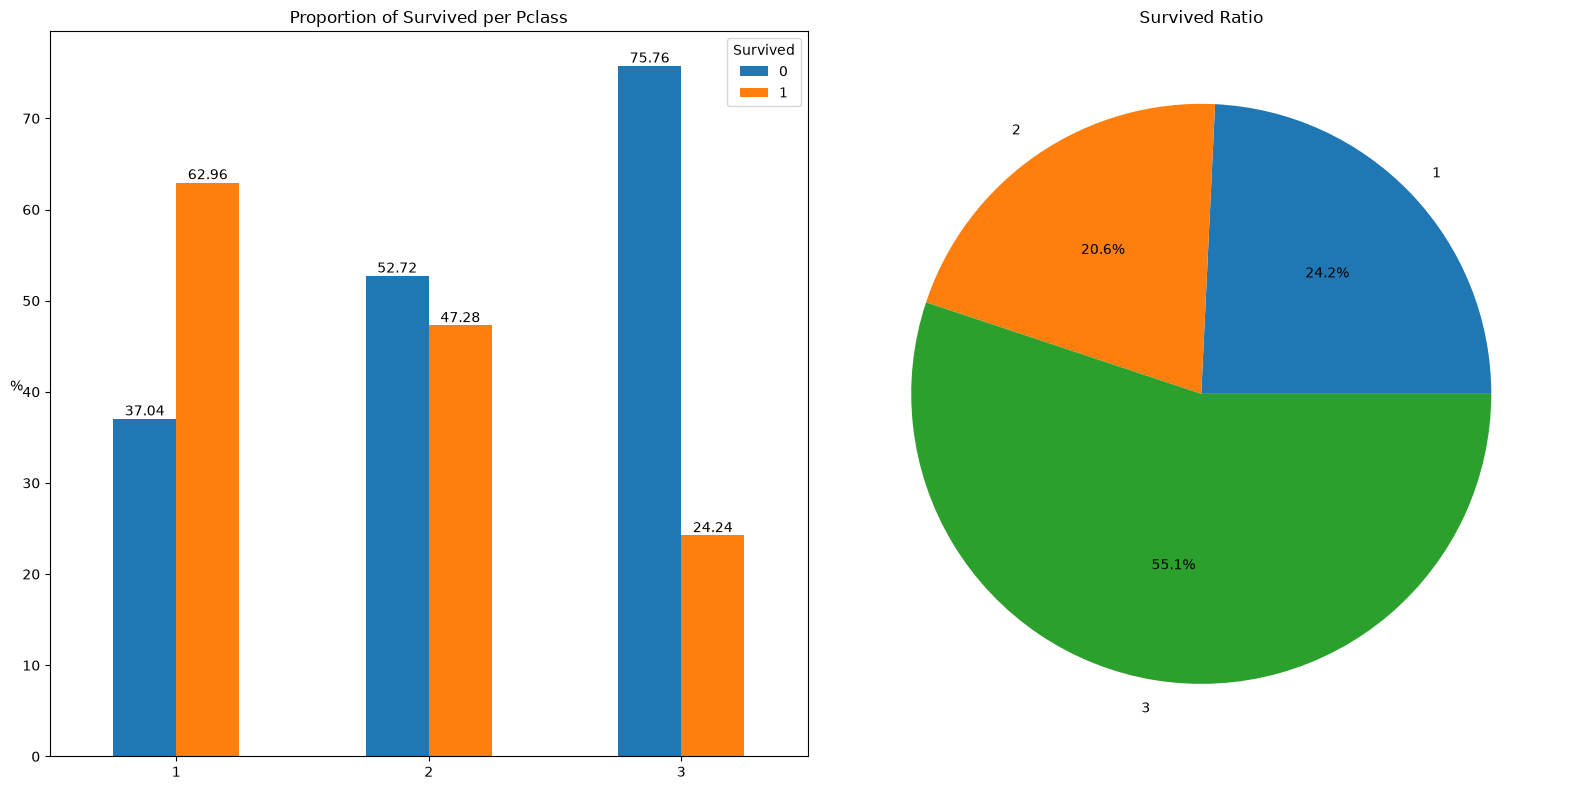

Result: statistically significant (p = 4.54925e-23)
Correlation (Cramér's V): 0.340 (moderate association)


In [206]:
gr = group_by_2_cols(df_train, col_1='Survived', col_2='Pclass')
plot_2_cols_chart(gr, col_1='Survived', col_2='Pclass')
is_significant(gr)

As expected, 1st class had the highest surval rate, while 3rd class had the lowest. It seemed that there was a strong positive correlation between Fare, Pclass, and Survival.

## Feature Engineering

### Name

Names are in the format of {Last Name}, {Title}. {First Name}. It would be useful to extract the titles and last names to gain information about classes and family relations

In [207]:
def extract_title_and_last_name(name: str):
    if not name or not name.strip():
        return None, None
    
    parts = name.split(', ')
    
    last_name = parts[0] if len(parts) > 0 else None  # Remove last char
    title = parts[1].split('. ')[0] if len(parts) > 1 else None
    
    return title, last_name
df_train[['Title', 'Lastname']] = df_train['Name'].apply(lambda x: pd.Series(extract_title_and_last_name(x)))
df_train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Lastname
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,Braund
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,Cumings
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,Heikkinen
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,Futrelle
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,Allen


Mapping specific titles to generalized groups to create high-signal feature that explicitly encodes the social hierarchy including Gender, Age, Status. Some titles only exist in train or test dataset, it is best to create a universal mapping to cover as many titles as possible.

In [208]:
title_mapping = {
    'Mr': 'Mr',
    'Mrs': 'Mrs',
    'Miss': 'Miss',
    'Ms': 'Miss',
    'Master': 'Master',
    'Mme': 'Mrs',     # French for Mrs
    'Mlle': 'Miss',   # French for Miss
    'the Count': 'Noble',
    'the Countess': 'Noble_Female',
    'Count': 'Noble',
    'Coutess': 'Noble_Female',
    'Don': 'Noble',   # Not a Knight
    'Sir': 'Noble',   # Knight
    'Jonkheer': 'Noble',
    'Jonkvrouw': 'Noble_Female',
    'Earl': 'Noble',
    'Lord': 'Noble',
    'Lady': 'Noble_Female',
    'Dame': 'Noble_Female',
    'Major': 'Military',
    'Col': 'Military',
    'Capt': 'Military',
    'Dr': 'Academic',
    'Prof': 'Academic',
    'Rev': 'Religious'
}
    
df_train['Title'] = df_train['Title'].map(title_mapping)
df_train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Lastname
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,Braund
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,Cumings
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,Heikkinen
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,Futrelle
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,Allen


Total number of Title: 891


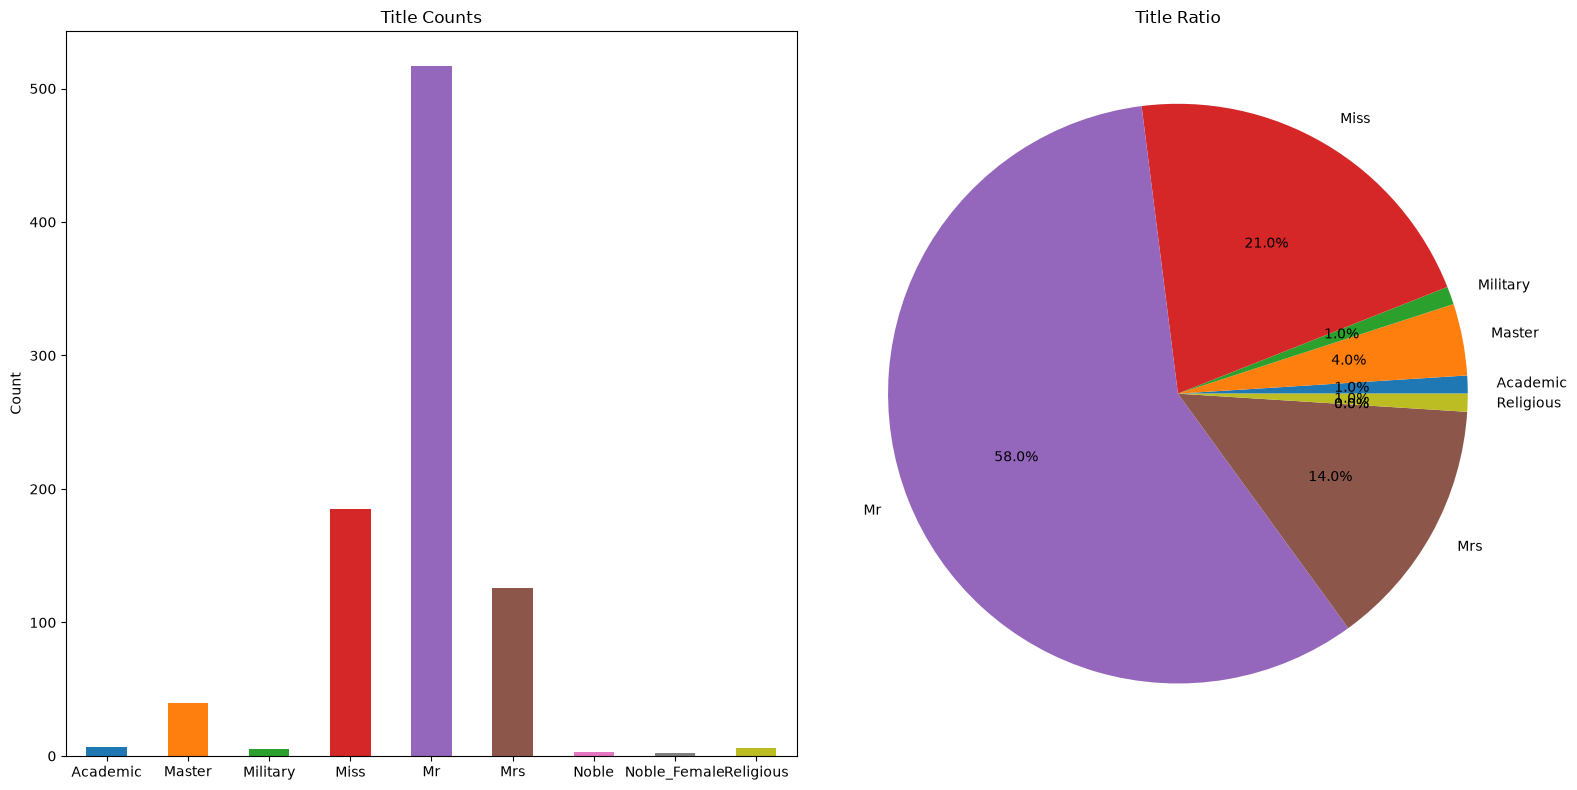

In [209]:
group_by_col_and_plot(df_train, 'Title')

Survived        0    1
Title                 
Academic        4    3
Master         17   23
Military        3    2
Miss           55  130
Mr            436   81
Mrs            26  100
Noble           2    1
Noble_Female    0    2
Religious       6    0


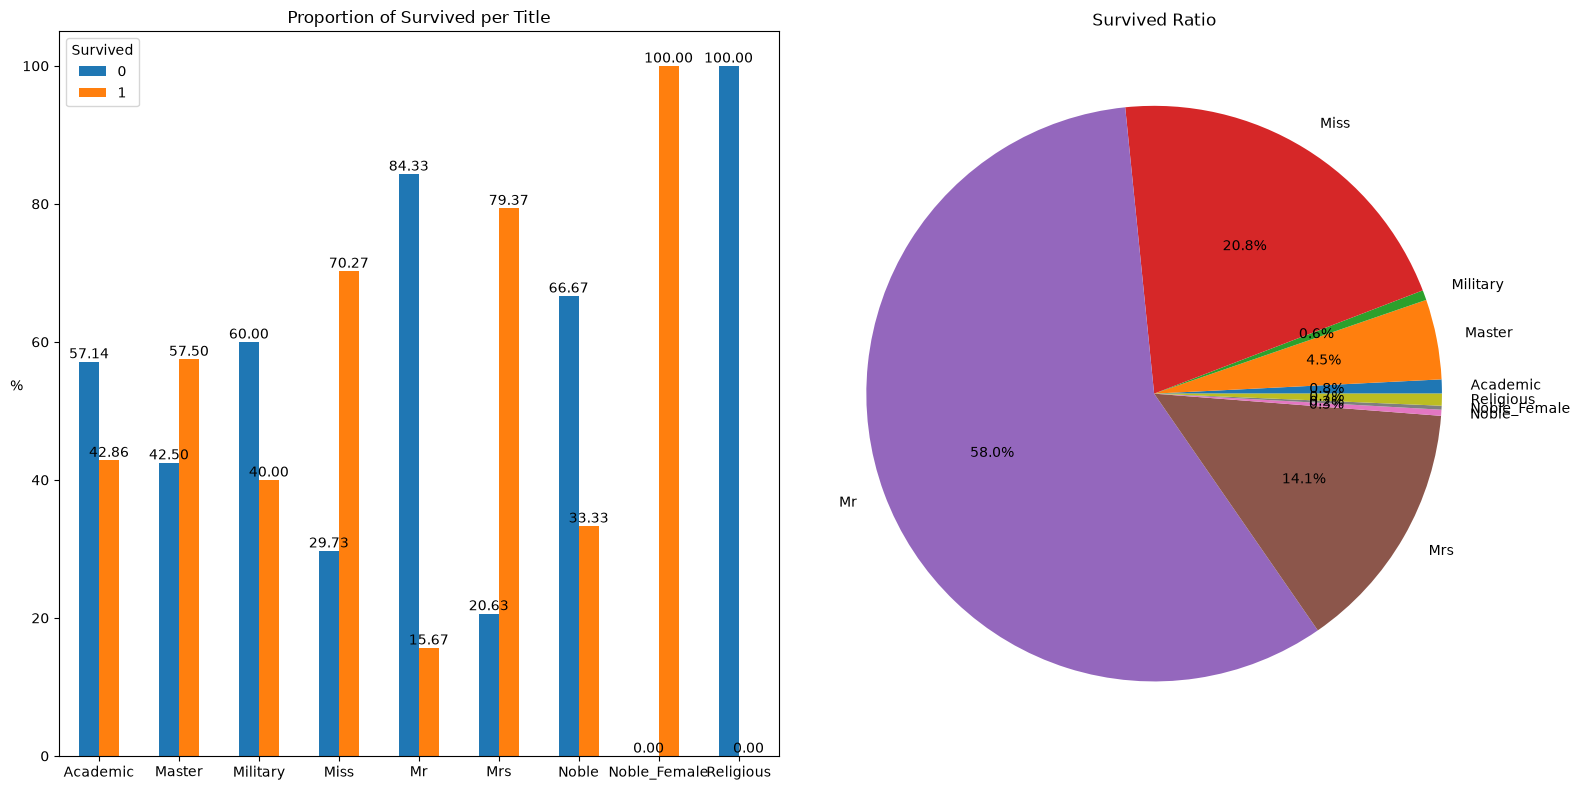

Result: statistically significant (p = 4.68467e-59)
Correlation (Cramér's V): 0.575 (moderate association)


In [210]:
gr = group_by_2_cols(df_train, col_1='Survived', col_2='Title')
plot_2_cols_chart(gr, col_1='Survived', col_2='Title')
is_significant(gr)

It seems that Master, Miss, Mrs, and Noble_Female titles are titles strongly correlated to Survival

### Family Size

Combine SibSp and Parch as FamilySize

FamilySize = SibSp + Parch + 1 to account for all members in the family including the person we are looking at

In [211]:
def create_family_size(df):
    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df.drop(['SibSp', 'Parch'], axis=1)

    return df

df_train = create_family_size(df_train)
df_train.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Lastname,FamilySize
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,Braund,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,Cumings,2
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,Heikkinen,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,Futrelle,2
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,Allen,1


Total number of FamilySize: 891


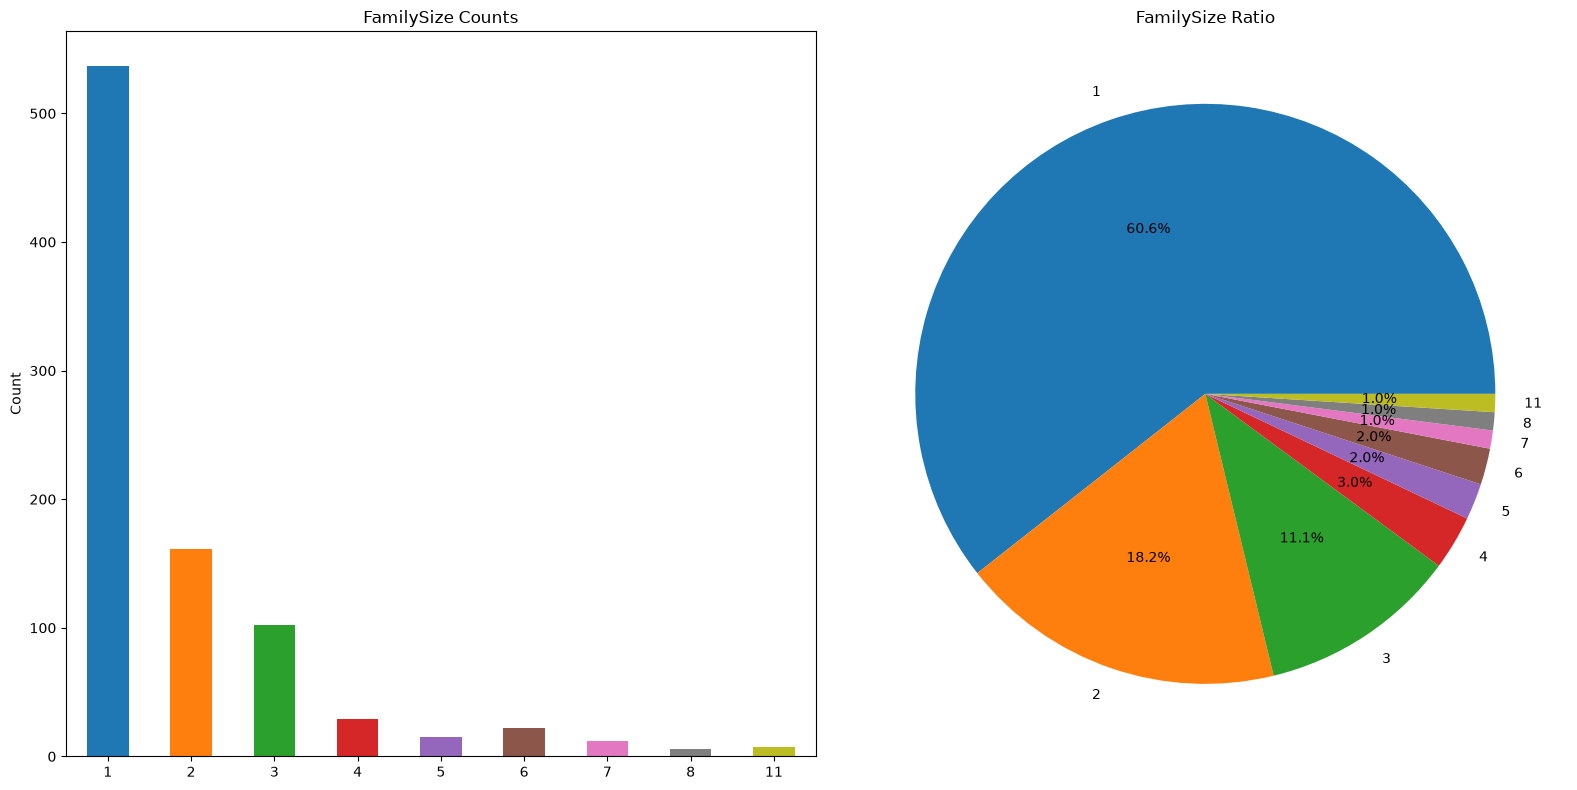

In [212]:
group_by_col_and_plot(df_train, 'FamilySize')

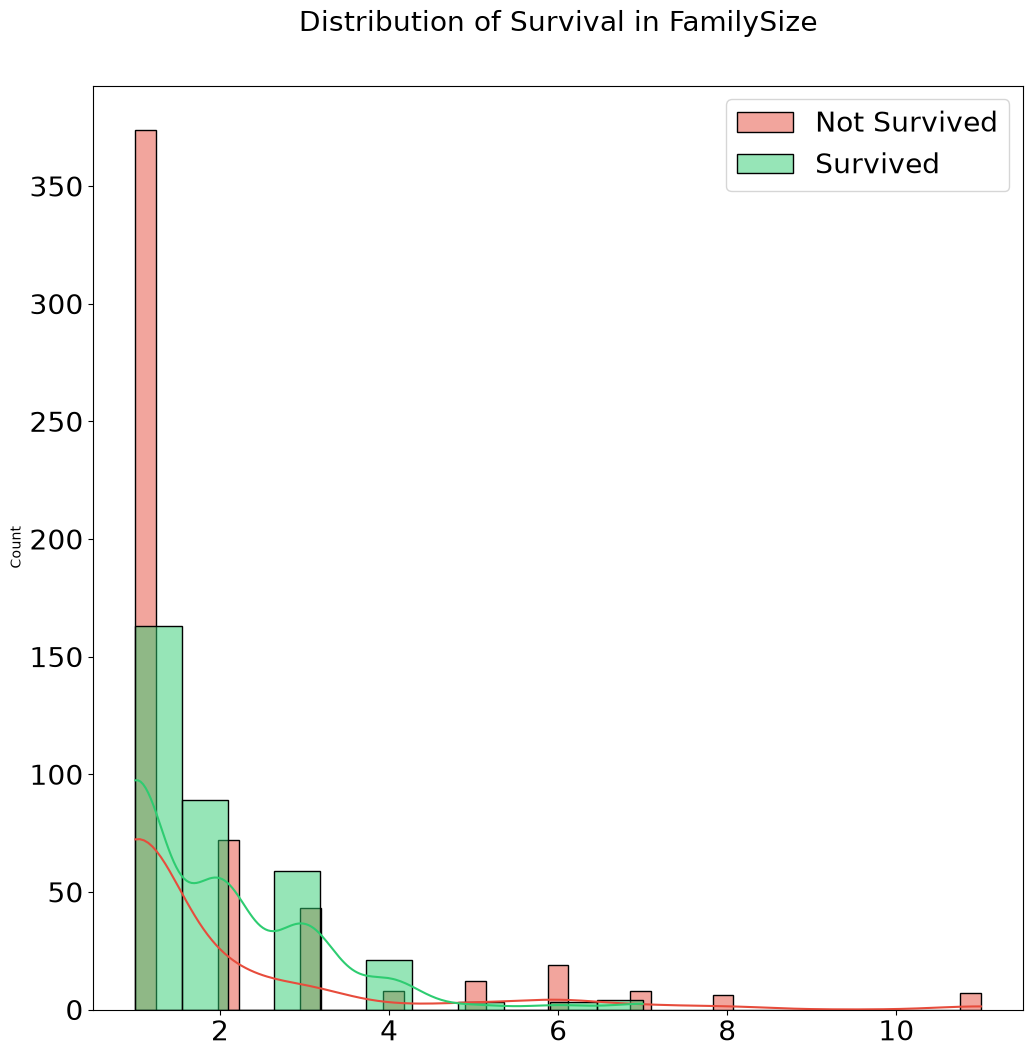

In [213]:
distribution_plot(df_train, col='FamilySize')

Survived      0    1
FamilySize          
1           374  163
2            72   89
3            43   59
4             8   21
5            12    3
6            19    3
7             8    4
8             6    0
11            7    0


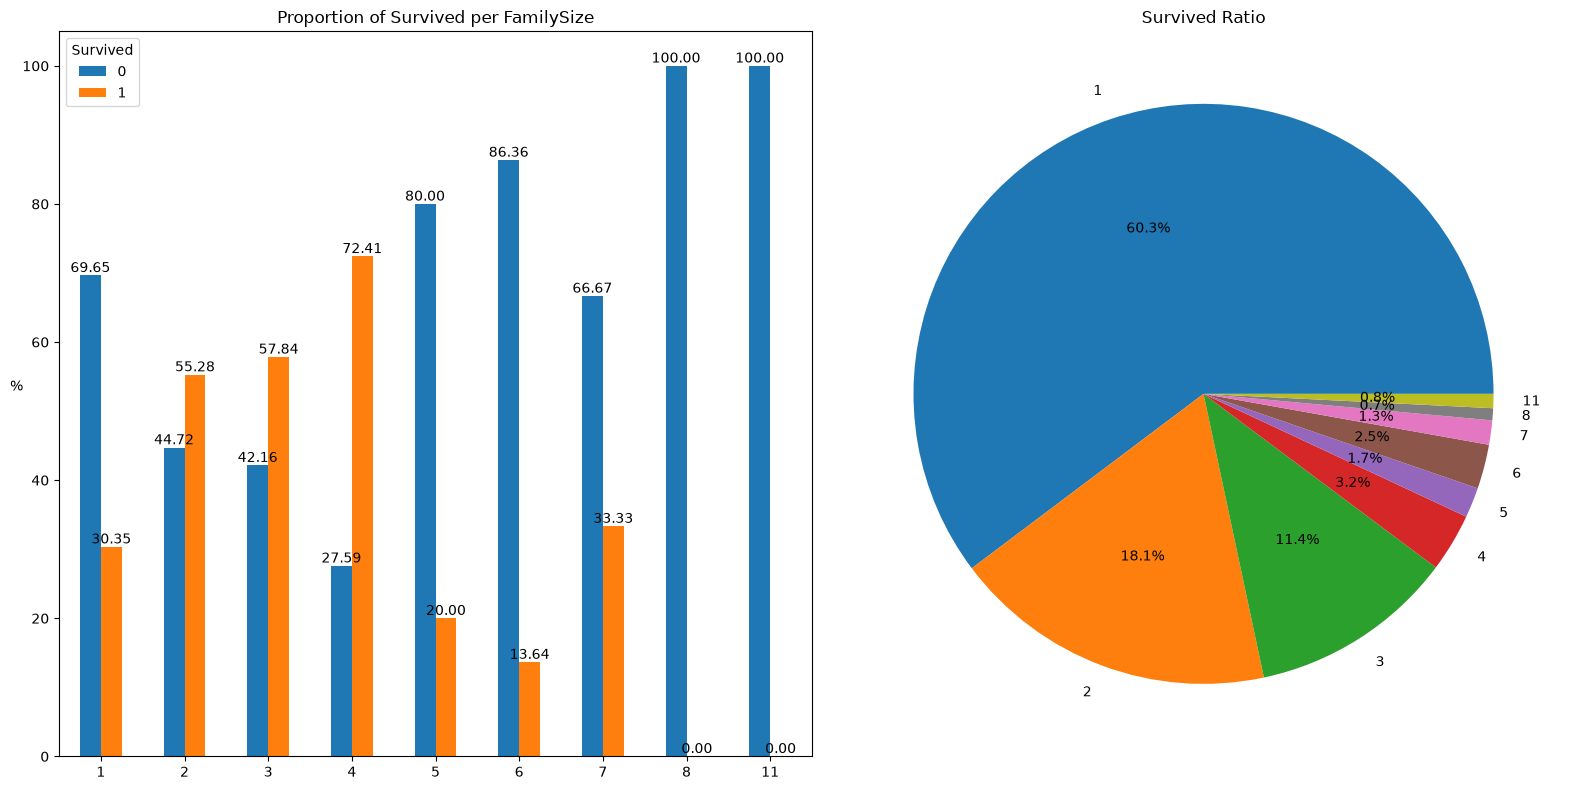

Result: statistically significant (p = 3.57967e-14)
Correlation (Cramér's V): 0.301 (moderate association)


In [214]:
gr = group_by_2_cols(df_train, col_1='Survived', col_2='FamilySize')
plot_2_cols_chart(gr, col_1='Survived', col_2='FamilySize')
is_significant(gr)

Family Sizes 2 - 4 show favorable survival ratios (>55%).\
Solo travelers had 30.4% survival rate, similar to overall survival as they account for most of the passengers.\
Large families size 5-11 had extremely poor survivalbility.

### Age

#### Fill missing ages

In [215]:
missing_mask = df_train['Age'].isna()

def fill_missing_ages(df):
    df = df.fillna({'Age': df.groupby(['Title', 'Pclass', 'FamilySize', 'Sex'], observed=False)['Age'].transform('median')})
    df = df.fillna({'Age': df.groupby(['Title'], observed=False)['Age'].transform('median')})
    df = df.fillna({'Age': df.groupby(['Pclass'], observed=False)['Age'].transform('median')})
    
    return df

df_train = fill_missing_ages(df_train)

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_train[missing_mask])

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Lastname,FamilySize
5,0,3,"Moran, Mr. James",male,27.00,0,0,330877,8.4583,NaN,Q,Mr,Moran,1
17,1,2,"Williams, Mr. Charles Eugene",male,30.00,0,0,244373,13.0000,NaN,S,Mr,Williams,1
19,1,3,"Masselmani, Mrs. Fatima",female,47.00,0,0,2649,7.2250,NaN,C,Mrs,Masselmani,1
26,0,3,"Emir, Mr. Farred Chehab",male,27.00,0,0,2631,7.2250,NaN,C,Mr,Emir,1
28,1,3,"O'Dwyer, Miss. Ellen ""Nellie""",female,22.00,0,0,330959,7.8792,NaN,Q,Miss,O'Dwyer,1
29,0,3,"Todoroff, Mr. Lalio",male,27.00,0,0,349216,7.8958,NaN,S,Mr,Todoroff,1
31,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,38.50,1,0,PC 17569,146.5208,B78,C,Mrs,Spencer,2
32,1,3,"Glynn, Miss. Mary Agatha",female,22.00,0,0,335677,7.7500,NaN,Q,Miss,Glynn,1
36,1,3,"Mamee, Mr. Hanna",male,27.00,0,0,2677,7.2292,NaN,C,Mr,Mamee,1
42,0,3,"Kraeff, Mr. Theodor",male,27.00,0,0,349253,7.8958,NaN,C,Mr,Kraeff,1


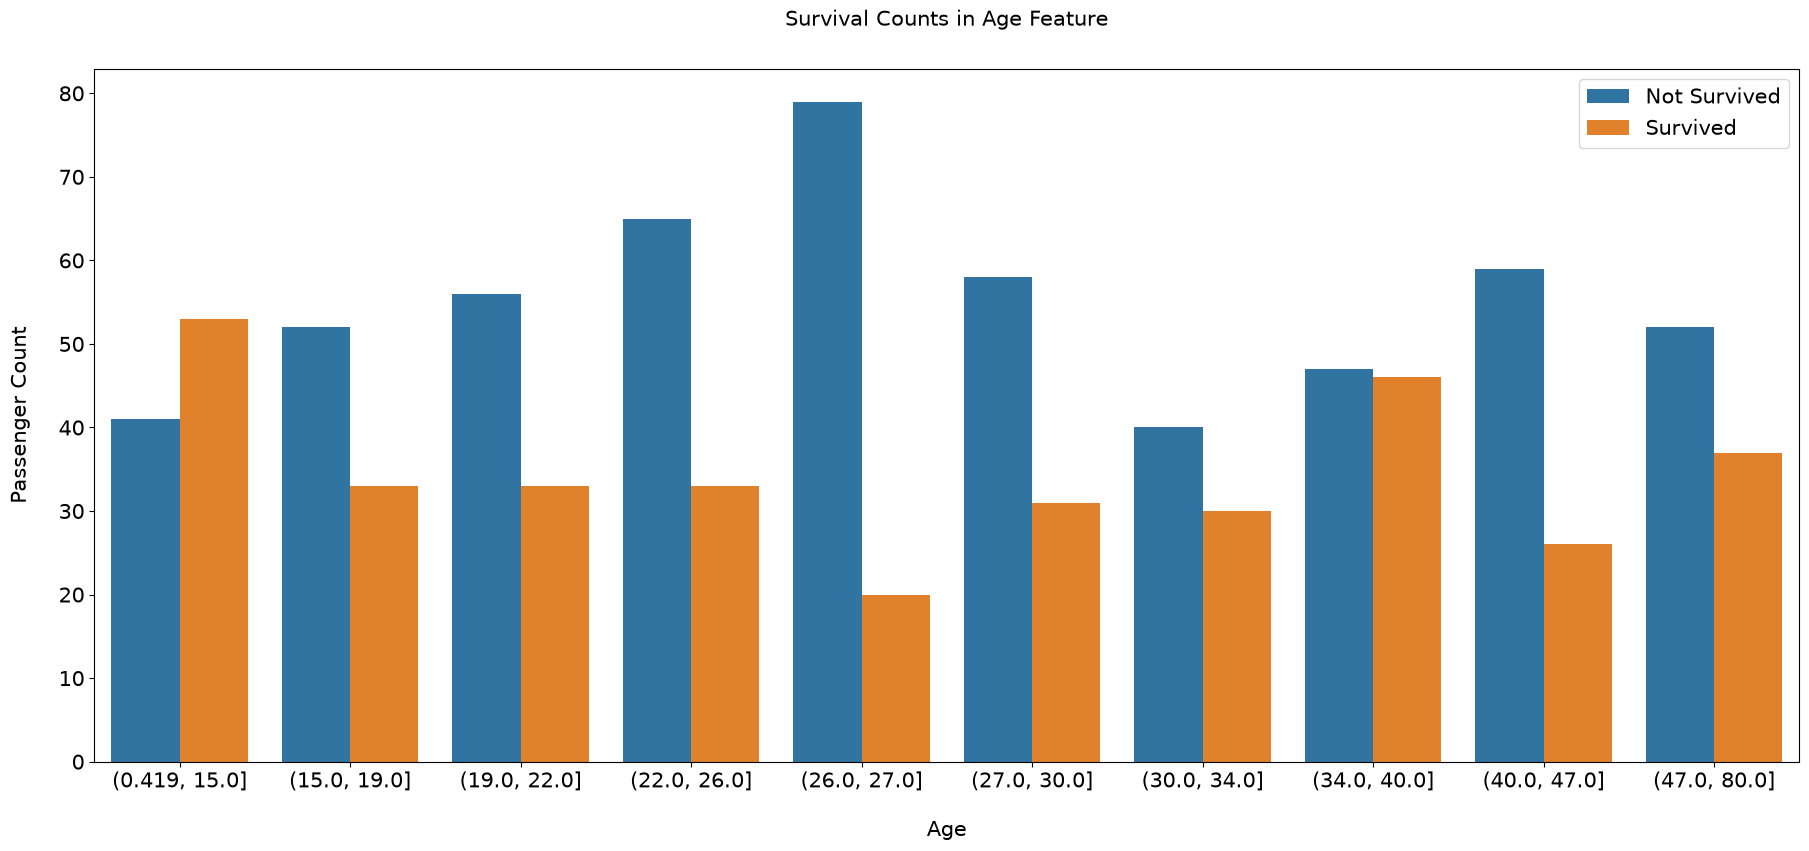

In [216]:
age_survive = pd.DataFrame({
    'Age': pd.qcut(df_train['Age'], q=10, duplicates='drop'),
    'Survived': df_train['Survived']
})
fig, axs = plt.subplots(figsize=(22, 9))
sns.countplot(x='Age', hue='Survived', data=age_survive)

plt.xlabel('Age', size=15, labelpad=20)
plt.ylabel('Passenger Count', size=15, labelpad=20)
plt.tick_params(axis='x', labelsize=15)
plt.tick_params(axis='y', labelsize=15)

plt.legend(['Not Survived', 'Survived'], loc='upper right', prop={'size': 15})
plt.title('Survival Counts in {} Feature'.format('Age'), size=15, y=1.05)

plt.show()

Age 0-14 show favorable survival ratio. And suprisingly age 30-40 also had a high survival ratio\

In [217]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_train[(df_train['Age'] >= 30) & (df_train['Age'] <= 40)].sort_values('Sex', ascending=True))

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,Lastname,FamilySize
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,Cumings,2
383,1,1,"Holverson, Mrs. Alexander Oskar (Mary Aline To...",female,35.0,1,0,113789,52.0000,NaN,S,Mrs,Holverson,2
375,1,1,"Meyer, Mrs. Edgar Joseph (Leila Saks)",female,38.5,1,0,PC 17604,82.1708,NaN,C,Mrs,Meyer,2
357,0,2,"Funk, Miss. Annie Clemmer",female,38.0,0,0,237671,13.0000,NaN,S,Miss,Funk,1
346,1,2,"Smith, Miss. Marion Elsie",female,40.0,0,0,31418,13.0000,NaN,S,Miss,Smith,1
334,1,1,"Frauenthal, Mrs. Henry William (Clara Heinshei...",female,38.5,1,0,PC 17611,133.6500,NaN,S,Mrs,Frauenthal,2
716,1,1,"Endres, Miss. Caroline Louise",female,38.0,0,0,PC 17757,227.5250,C45,C,Miss,Endres,1
328,1,3,"Goldsmith, Mrs. Frank John (Emily Alice Brown)",female,31.0,1,1,363291,20.5250,NaN,S,Mrs,Goldsmith,3
327,1,2,"Ball, Mrs. (Ada E Hall)",female,36.0,0,0,28551,13.0000,D,S,Mrs,Ball,1
325,1,1,"Young, Miss. Marie Grice",female,36.0,0,0,PC 17760,135.6333,C32,C,Miss,Young,1


In [218]:
# Check Gender Balance
print(df_train[(df_train['Age'] >= 30) & (df_train['Age'] <= 40)]['Sex'].value_counts())

# Check Class Balance
print(df_train[(df_train['Age'] >= 30) & (df_train['Age'] <= 40)]['Pclass'].value_counts())

# Cross-tabulate Check
print(pd.crosstab(df_train[(df_train['Age'] >= 30) & (df_train['Age'] <= 40)]['Pclass'], df_train[(df_train['Age'] >= 30) & (df_train['Age'] <= 40)]['Sex']))
print(pd.crosstab(df_train[(df_train['Age'] >= 30) & (df_train['Age'] <= 40)]['Sex'], df_train[(df_train['Age'] >= 30) & (df_train['Age'] <= 40)]['Survived']))
print(pd.crosstab(df_train[(df_train['Age'] >= 30) & (df_train['Age'] <= 40)]['Pclass'], df_train[(df_train['Age'] >= 30) & (df_train['Age'] <= 40)]['Survived']))  

Sex
male      124
female     76
Name: count, dtype: int64
Pclass
3    74
1    64
2    62
Name: count, dtype: int64
Sex     female  male
Pclass              
1           37    27
2           22    40
3           17    57
Survived   0   1
Sex             
female    11  65
male      98  26
Survived   0   1
Pclass          
1         14  50
2         36  26
3         59  15


It seems like this can be explained by the large portion of people from this age group are either female or first class passenger: 103/200(>50%), while the total number of survivors of this group is only 91

### Fare

#### Fill missing fares

In [219]:
def fill_missing_fares(df):
    df['Fare'] = df['Fare'].replace(0, np.nan)
    df = df.fillna({'Fare': df.groupby(['Title', 'Pclass', 'FamilySize'], observed=False)['Fare'].transform('median')})
    df = df.fillna({'Fare': df.groupby(['Title', 'Pclass'], observed=False)['Fare'].transform('median')})
    
    return df

df_train = fill_missing_fares(df_train)

### Embarked

In [220]:
def fill_missing_embarked(df):
    df = df.fillna({'Embarked': df.groupby(['Title', 'Pclass', 'FamilySize'], observed=False)['Embarked'].transform(lambda x: x.mode()[0])})
    df = df.fillna({'Embarked': df.groupby(['Lastname'], observed=False)['Embarked'].transform(lambda x: x.mode()[0])})
    
    return df

df_train = fill_missing_embarked(df_train)

### Cabin

In [221]:
def convert_Cabin_to_Deck(df):
    df['Deck'] = df['Cabin'].str[0].fillna('Unknown')
    return df

df_train = convert_Cabin_to_Deck(df_train)

### Processed Data

In [222]:
df_train = df_train.drop(['Name', 'SibSp', 'Parch', 'Ticket', 'Cabin'], axis=1)

In [223]:
df_train.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,Title,Lastname,FamilySize,Deck
0,0,3,male,22.0,7.2500,S,Mr,Braund,2,Unknown
1,1,1,female,38.0,71.2833,C,Mrs,Cumings,2,C
2,1,3,female,26.0,7.9250,S,Miss,Heikkinen,1,Unknown
3,1,1,female,35.0,53.1000,S,Mrs,Futrelle,2,C
4,0,3,male,35.0,8.0500,S,Mr,Allen,1,Unknown


In [237]:
def build_features(df):
    """
    Prepare features for training by combining all preprocessing and feature engineering steps.
    
    Uses pre-defined functions:
    - extract_title_and_last_name(): Extract title and last name from Name
    - fill_missing_ages(): Fill missing ages using median by groups
    - fill_missing_fares(): Fill missing fares using median by groups
    - fill_missing_embarked(): Fill missing Embarked using mode by groups
    - convert_Cabin_to_Deck(): Convert Cabin to Deck letter
    - create_family_size(): Create FamilySize from SibSp and Parch
    
    Returns:
        pd.DataFrame: Processed dataframe ready for training
    """
    df = df.copy()
    
    # Extract title and last name from Name
    df[['Title', 'Lastname']] = df['Name'].apply(lambda x: pd.Series(extract_title_and_last_name(x)))
    
    # Map titles to standardized groups
    df['Title'] = df['Title'].map(title_mapping)
    
    # Create FamilySize
    df = create_family_size(df)
    
    # Fill missing values
    df = fill_missing_ages(df)
    df = fill_missing_fares(df)
    df = fill_missing_embarked(df)
    df = convert_Cabin_to_Deck(df)
    
    # Encode categorical variables
    df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
    df['Embarked'] = df['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})
    
    # Encode Deck (A-G, N for Unknown)
    deck_mapping = {
        'A': 0,
        'B': 1,
        'C': 2,
        'D': 3,
        'E': 4,
        'F': 5,
        'G': 6,
        'T': 7,
        'Unknown': 8
    }
    df['Deck'] = df['Deck'].map(deck_mapping)
    
    # Encode Title
    title_encode = {
        'Mr': 0, 'Mrs': 1, 'Miss': 2, 'Master': 3,
        'Noble': 4, 'Noble_Female': 5, 'Military': 6, 'Academic': 7, 'Religious': 8
    }
    df['Title'] = df['Title'].map(title_encode)
    
    # Convert Pclass to 0-indexed
    if 'Pclass' in df.columns:
        df['Pclass'] = df['Pclass'] - 1
    
    # Drop unnecessary columns
    cols_to_drop = ['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Cabin', 'Lastname']
    df = df.drop([col for col in cols_to_drop if col in df.columns], axis=1)
    
    return df

## Models

In [238]:
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from mlxtend.classifier import StackingCVClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
import sklearn

sklearn.set_config(enable_metadata_routing=True)

# Define models
base_lr_model = LogisticRegression(max_iter=1000, random_state=42)

randomForest = RandomForestClassifier(criterion='gini', 
                                    n_estimators=1100,
                                    max_depth=5,
                                    min_samples_split=4,
                                    min_samples_leaf=5,
                                    max_features='sqrt',
                                    oob_score=True,
                                    random_state=13,
                                    n_jobs=-1,
                                    verbose=1)

lgb = LGBMClassifier(n_estimators=300, max_depth=5, learning_rate=0.1, is_unbalanced=True, random_state=42)

gb = GradientBoostingClassifier(n_estimators=1000, max_depth=4, learning_rate=0.1, n_iter_no_change=30, random_state=42)

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=7,
    scale_pos_weight=1.65,  # Handle class imbalance
    random_state=42,
    n_jobs=-1,
    enable_categorical=True,
    eval_metric="logloss"
)

cat = CatBoostClassifier(iterations=100, depth=4, verbose=False, random_state=42)

# bagging = BaggingClassifier(
#     estimator=xgb, 
#     n_estimators=100, 
#     max_samples=0.8,  # Each estimator sees 80% of the data
#     random_state=1
# )

# Define meta-classifier

sclf = StackingCVClassifier(
    classifiers=[
        RandomForestClassifier(n_estimators=1100, max_depth=5, random_state=13, n_jobs=-1),
        XGBClassifier(n_estimators=300, max_depth=7, random_state=42),
        LGBMClassifier(n_estimators=300, max_depth=5, random_state=42),
        GradientBoostingClassifier(n_estimators=1000, max_depth=4, n_iter_no_change=30, random_state=42),
    ],
    meta_classifier=LogisticRegression(max_iter=1000, random_state=42),
    cv=5  # Increase for more robust meta-training
)
voting = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=1100, max_depth=5, random_state=13, n_jobs=-1)),
        ('xgb', XGBClassifier(n_estimators=300, max_depth=7, scale_pos_weight=1.65, random_state=42)),
        ('lgb', LGBMClassifier(n_estimators=300, max_depth=5, is_unbalanced=True, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=42)),
    ],
    voting='soft',  # Use probability predictions
    n_jobs=-1
)

## Training

In [226]:
import mlflow
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, f1_score

### Model Comparison

Compare all models across 5-fold cross-validation to identify top performers

In [ ]:
# Prepare data
df_train = pd.read_csv('../data/raw/train.csv')
df = build_features(df_train)

target_col = 'Survived'
X = df.drop(columns=[target_col])
y = df[target_col]

# Define all models to compare
models_to_test = {
    'RandomForest': randomForest,
    'XGBoost': xgb,
    'LightGBM': lgb,
    'GradientBoosting': gb,
    'StackingEnsemble': sclf,
    'VotingEnsemble': voting,
}

# Store results
results = {name: {'accuracy': [], 'recall': [], 'f1': []} for name in models_to_test.keys()}

# K-Fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=13)

for model_name, model in models_to_test.items():
    print(f"\n{'='*50}")
    print(f"Training {model_name}...")
    print(f"{'='*50}")

    with mlflow.start_run():
        mlflow.log_param("model", model_name)
        mlflow.log_param("cv_folds", 5)
        for fold, (train_index, test_index) in enumerate(skf.split(X, y)):
            X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
            y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
            
            # Train model
            model.fit(X_train_fold, y_train_fold)
            preds = model.predict(X_test_fold)
            
            # Calculate metrics
            acc = accuracy_score(y_test_fold, preds)
            rec = recall_score(y_test_fold, preds)
            f1 = f1_score(y_test_fold, preds)
            
            # Store metrics
            results[model_name]['accuracy'].append(acc)
            results[model_name]['recall'].append(rec)
            results[model_name]['f1'].append(f1)
            
            print(f"Fold {fold+1}: Acc={acc:.4f}, Recall={rec:.4f}, F1={f1:.4f}")
    
        # log mean/std after all folds
        mlflow.log_metrics({
            "accuracy_mean": np.mean(results[model_name]['accuracy']),
            "accuracy_std": np.std(results[model_name]['accuracy']),
            "recall_mean": np.mean(results[model_name]['recall']),
            "recall_std": np.std(results[model_name]['recall']),
            "f1_mean": np.mean(results[model_name]['f1']),
            "f1_std": np.std(results[model_name]['f1'])
        })

# Rank models by F1 score
print(f"\n{'='*50}")
print("FINAL RANKINGS (by F1 Score):")
print(f"{'='*50}")
ranked = sorted(results.items(), key=lambda x: np.mean(x[1]['f1']), reverse=True)
for rank, (name, metrics) in enumerate(ranked, 1):
    print(f"{rank}. {name}: F1={np.mean(metrics['f1']):.4f}")



Training RandomForest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 61 concurrent workers.
[Parallel(n_jobs=-1)]: Done  78 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 328 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 678 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 1100 out of 1100 | elapsed:    1.3s finished
[Parallel(n_jobs=61)]: Using backend ThreadingBackend with 61 concurrent workers.
[Parallel(n_jobs=61)]: Done  78 tasks      | elapsed:    0.0s
[Parallel(n_jobs=61)]: Done 328 tasks      | elapsed:    0.0s
[Parallel(n_jobs=61)]: Done 678 tasks      | elapsed:    0.1s
[Parallel(n_jobs=61)]: Done 1100 out of 1100 | elapsed:    0.1s finished


Fold 1: Acc=0.8045, Recall=0.6667, F1=0.7244


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 61 concurrent workers.
[Parallel(n_jobs=-1)]: Done  78 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 328 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 678 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done 1100 out of 1100 | elapsed:    1.6s finished
[Parallel(n_jobs=61)]: Using backend ThreadingBackend with 61 concurrent workers.
[Parallel(n_jobs=61)]: Done  78 tasks      | elapsed:    0.0s
[Parallel(n_jobs=61)]: Done 328 tasks      | elapsed:    0.0s
[Parallel(n_jobs=61)]: Done 678 tasks      | elapsed:    0.1s
[Parallel(n_jobs=61)]: Done 1100 out of 1100 | elapsed:    0.1s finished


Fold 2: Acc=0.8539, Recall=0.7941, F1=0.8060


...

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 61 concurrent workers.
[Parallel(n_jobs=-1)]: Done  78 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 328 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 678 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 1100 out of 1100 | elapsed:    1.3s finished
[Parallel(n_jobs=61)]: Using backend ThreadingBackend with 61 concurrent workers.
[Parallel(n_jobs=61)]: Done  78 tasks      | elapsed:    0.0s
[Parallel(n_jobs=61)]: Done 328 tasks      | elapsed:    0.0s
[Parallel(n_jobs=61)]: Done 678 tasks      | elapsed:    0.1s
[Parallel(n_jobs=61)]: Done 1100 out of 1100 | elapsed:    0.1s finished


Fold 4: Acc=0.8315, Recall=0.6618, F1=0.7500


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 61 concurrent workers.
[Parallel(n_jobs=-1)]: Done  78 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done 328 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 678 tasks      | elapsed:    0.8s
[Parallel(n_jobs=-1)]: Done 1100 out of 1100 | elapsed:    1.3s finished
[Parallel(n_jobs=61)]: Using backend ThreadingBackend with 61 concurrent workers.
[Parallel(n_jobs=61)]: Done  78 tasks      | elapsed:    0.0s
[Parallel(n_jobs=61)]: Done 328 tasks      | elapsed:    0.0s
[Parallel(n_jobs=61)]: Done 678 tasks      | elapsed:    0.1s
[Parallel(n_jobs=61)]: Done 1100 out of 1100 | elapsed:    0.1s finished


Fold 5: Acc=0.7921, Recall=0.6812, F1=0.7176

Training XGBoost...
Fold 1: Acc=0.7821, Recall=0.6957, F1=0.7111
Fold 2: Acc=0.8034, Recall=0.8088, F1=0.7586
Fold 3: Acc=0.8876, Recall=0.8676, F1=0.8551
Fold 4: Acc=0.8034, Recall=0.7500, F1=0.7445
Fold 5: Acc=0.7528, Recall=0.6232, F1=0.6615

Training LightGBM...
[LightGBM] [Warning] Unknown parameter: is_unbalanced
[LightGBM] [Warning] Unknown parameter: is_unbalanced
[LightGBM] [Info] Number of positive: 273, number of negative: 439
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004004 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 215
[LightGBM] [Info] Number of data points in the train set: 712, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.383427 -> initscore=-0.475028
[LightGBM] [Info] Start training from score -0.475028
[LightGBM] [Warning] No furth

ValueError: Input X contains NaN.
GradientBoostingClassifier does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [231]:
nan_locations = df.isna().stack()

nan_locations = nan_locations[nan_locations]

for (row, column), _ in nan_locations.items():
    print(f"Row: {row}, Column: {column}")

Row: 339, Column: Deck


In [236]:
df = pd.read_csv('../data/raw/train.csv')
print(df.iloc[339])

PassengerId                             340
Survived                                  0
Pclass                                    1
Name           Blackwell, Mr. Stephen Weart
Sex                                    male
Age                                    45.0
SibSp                                     0
Parch                                     0
Ticket                               113784
Fare                                   35.5
Cabin                                     T
Embarked                                  S
Name: 339, dtype: object


### Fine-tune Top 2 Models

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Extract top 2 models from results above
# Example: if XGBoost and VotingEnsemble are top 2, update the model names below
top_2_names = ['VotingEnsemble', 'XGBoost']  # UPDATE based on comparison results

print(f"\nFine-tuning top 2 models: {top_2_names}")
print(f"{'='*60}\n")

# Fine-tuned XGBoost hyperparameters
xgb_tuned = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=1.65,
    random_state=42,
    n_jobs=-1
)

# Fine-tuned LightGBM hyperparameters
lgb_tuned = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    is_unbalanced=True,
    random_state=42
)

# Fine-tuned Gradient Boosting
gb_tuned = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    min_samples_split=5,
    min_samples_leaf=2,
    subsample=0.8,
    random_state=42
)

# Fine-tuned Voting Ensemble (with tuned base learners)
voting_tuned = VotingClassifier(
    estimators=[
        ('xgb', xgb_tuned),
        ('lgb', lgb_tuned),
        ('gb', gb_tuned),
    ],
    voting='soft',
    n_jobs=-1
)

# Tuned models dictionary
tuned_models = {
    'XGBoost_Tuned': xgb_tuned,
    'LightGBM_Tuned': lgb_tuned,
    'GradientBoosting_Tuned': gb_tuned,
    'VotingEnsemble_Tuned': voting_tuned,
}

# Train and evaluate tuned models
tuned_results = {name: {'accuracy': [], 'recall': [], 'f1': []} for name in tuned_models.keys()}

for model_name, model in tuned_models.items():
    print(f"Training {model_name}...")
    
    for fold, (train_index, test_index) in enumerate(kf.split(X)):
        X_train_fold, X_test_fold = X.iloc[train_index], X.iloc[test_index]
        y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]
        
        model.fit(X_train_fold, y_train_fold)
        preds = model.predict(X_test_fold)
        
        acc = accuracy_score(y_test_fold, preds)
        rec = recall_score(y_test_fold, preds)
        f1 = f1_score(y_test_fold, preds)
        
        tuned_results[model_name]['accuracy'].append(acc)
        tuned_results[model_name]['recall'].append(rec)
        tuned_results[model_name]['f1'].append(f1)
    
    print(f"  Accuracy: {np.mean(tuned_results[model_name]['accuracy']):.4f} ± {np.std(tuned_results[model_name]['accuracy']):.4f}")
    print(f"  F1 Score: {np.mean(tuned_results[model_name]['f1']):.4f} ± {np.std(tuned_results[model_name]['f1']):.4f}\n")

# Compare baseline vs tuned
print(f"\n{'='*60}")
print("BASELINE vs TUNED COMPARISON:")
print(f"{'='*60}\n")
for base_name in ['XGBoost', 'LightGBM', 'GradientBoosting', 'VotingEnsemble']:
    tuned_name = f"{base_name}_Tuned"
    if base_name in results and tuned_name in tuned_results:
        base_f1 = np.mean(results[base_name]['f1'])
        tuned_f1 = np.mean(tuned_results[tuned_name]['f1'])
        improvement = ((tuned_f1 - base_f1) / base_f1) * 100
        print(f"{base_name}:")
        print(f"  Baseline F1: {base_f1:.4f}")
        print(f"  Tuned F1:    {tuned_f1:.4f}")
        print(f"  Improvement: {improvement:+.2f}%\n")

<VSCode.Cell id="#VSC-8cfa7b11" language="python">
def showFalseClassifications(df, preds, labels):
    indices = np.where(preds != labels)[0]

    print(df.iloc[indices].sort_valyes('Survived'))

def showTrueClassification(df, preds, labels):
    indices = np.where(preds == labels)[0]

    print(df.iloc[indices].sort_values('Survived'))

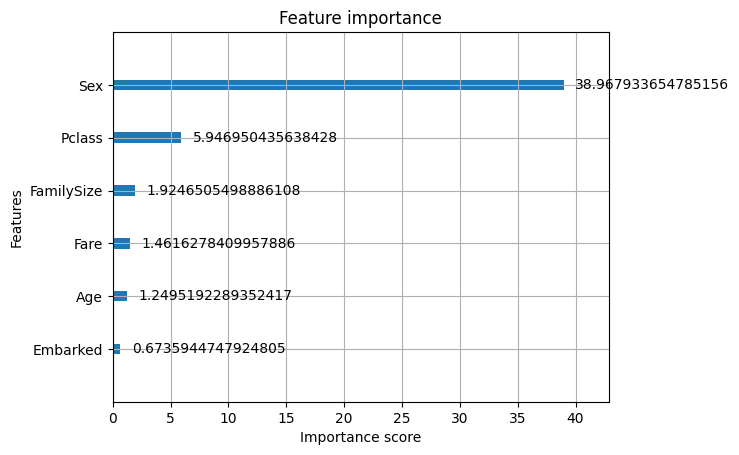

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Plot feature importance based on 'weight' (default), 'gain', or 'cover'
plot_importance(model, importance_type='gain', max_num_features=15)
plt.show()

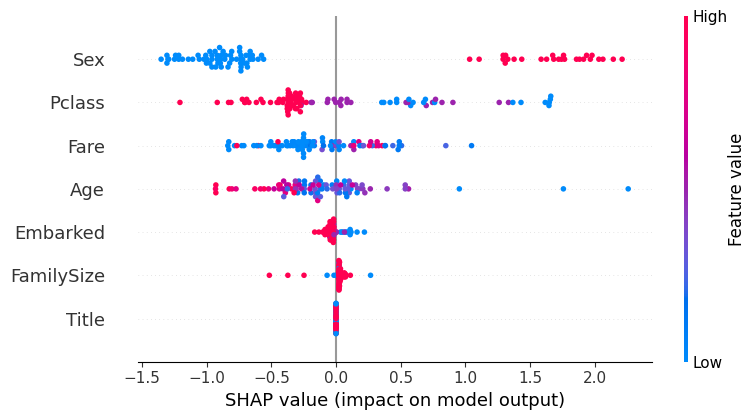

In [ ]:
import shap

# Create explainer and calculate values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_fold)

# Visualize
shap.summary_plot(shap_values, X_test_fold)

In [ ]:
# Dump model to text with statistics
model.get_booster().dump_model('model.txt', with_stats=True)

# Read and parse the file to extract split patterns
import re
with open('model.txt', 'r') as f:
    txt_model = f.read()

# Extract patterns like [f2<2.45]
splits = re.findall(r'\[f([0-9]+)<([0-9.e-]+)\]', txt_model)
print(splits)

[]


## Submission

In [ ]:
test_df = pd.read_csv('../data/raw/test.csv')
passengerId = test_df['PassengerId']
test_df = build_features(test_df)
preds = model.predict(test_df)
submission = pd.DataFrame({
    'PassengerId': passengerId,
    'Survived': preds
})
submission.head()
submission.to_csv('../data/raw/gender_submission.csv', index=False)

NameError: name 'sclf' is not defined